In [19]:
# This Notebook is used to analyse the noise performances of the DRE from data files


In [8]:
# imports
import matplotlib.pyplot as plt
import os
import readData as rddt
import general_tools as gt


In [16]:
#path = '/Users/laurent/data/20241011-2/'
path = '/Users/laurent/data/TestPlan21-perfo/'
testDir = '20241031_163105_lockingLoop-col2'
dataDir = 'dmx_data'


In [9]:
# Parameters for the spectral analysis. The unit seems to be per sqrt(Hz). I don't know why...
xlabel = r'Frequencies $(Hz)$'
#ylabel = r'Noise $\left(V_{rms} /\sqrt{Hz}\right)$'
ylabel = r'Noise $\left( \frac{V_{rms}} {\sqrt{Hz}} \right)$'
scaling = 'spectrum'
#scaling = 'density'
ymin = 1e-9
ymax = 1e-5

['error_start_closed_loop_C2.fits']
  Processing error file  error_start_closed_loop_C2.fits
results plotted in file /Users/laurent/data/TestPlan21-perfo/PLOTS/loop.png


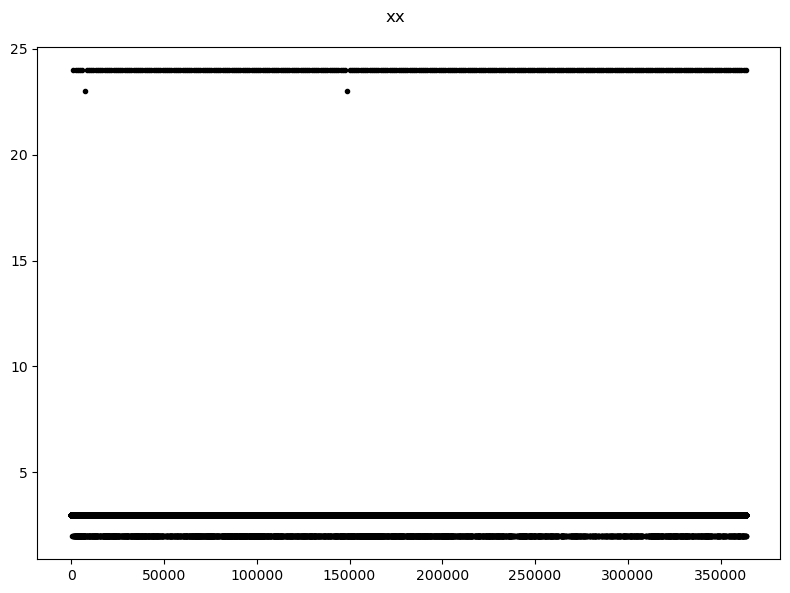

In [22]:
nPoints = 1000
col = dir[-1]
fullPath = os.path.join(os.path.join(path, testDir), dataDir)
plotDirname = "PLOTS"
pathPlot = os.path.join(path, plotDirname)
gt.createdir(pathPlot)
plotFileName = os.path.join(pathPlot, 'loop.png'.format(col))


suffix = "_C{0:}.fits".format(col)

files = [f for f in os.listdir(fullPath) \
         if os.path.isfile(os.path.join(fullPath, f)) \
         and f[-8:] == suffix]
print(files)

file = files[0]

#---------------------------------------------
# Processing Error data
print("  Processing error file ", file)

colData, ctrl = rddt.readScienceFile(os.path.join(fullPath, file), perPix=True)
pix6 = colData[6, :]

fig = plt.figure(figsize=(8, 6))
plt.suptitle("xx".format(col))
ax = fig.add_subplot(1, 1, 1)
ax.plot(pix6, '.', color='k', label='Error pixel 6')
fig.tight_layout()

plt.savefig(plotFileName, dpi=300, bbox_inches='tight')
print("results plotted in file " + plotFileName)

